In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams.update({
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
})

In [2]:
# Крок 1. Завантаження й огляд даних
# Fashion-MNIST - чорно-білі картинки одягу 28x28. keras віддає їх уже поділеними на train і test. y
# - номер класу від 0 до 9 (десять видів одягу), назви кладемо в окремий список для підписів.
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
x_train_full.shape, y_train_full.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [3]:
# Значення пікселів - цілі числа від 0 до 255 (яскравість). Датасет готовий, пропусків тут не буває.
print("тип:", x_train_full.dtype, "| мін:", x_train_full.min(), "| макс:", x_train_full.max())

тип: uint8 | мін: 0 | макс: 255


In [4]:
# Баланс класів у train - скільки прикладів кожного виду одягу. По 6000 на клас, тобто класи рівні.
pd.Series(y_train_full).value_counts().sort_index()

0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64

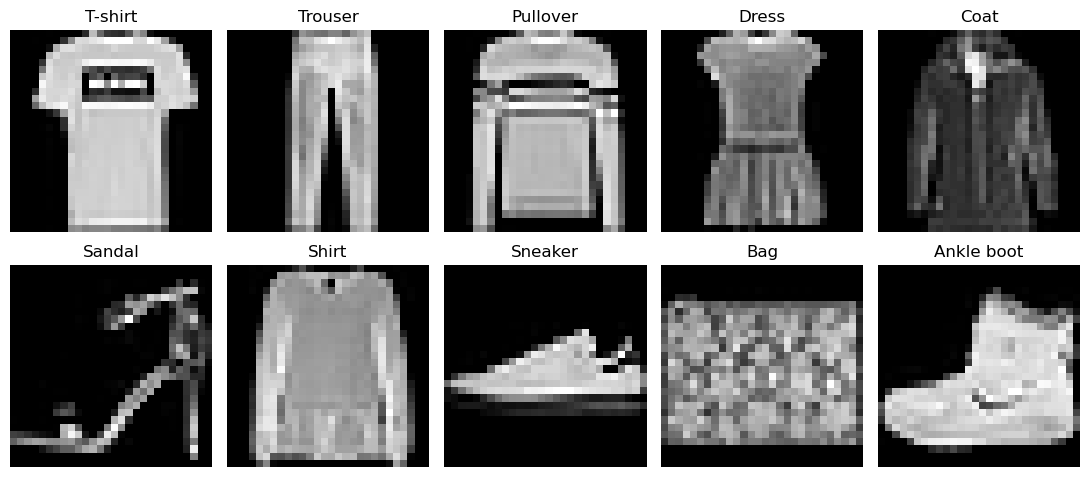

In [5]:
# Дивимось по одному прикладу кожного класу з його назвою, щоб побачити, з чим працюємо.
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for cls, ax in enumerate(axes.ravel()):
    idx = np.argmax(y_train_full == cls)
    ax.imshow(x_train_full[idx], cmap="gray")
    ax.set_title(class_names[cls])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# Крок 2. Підготовка даних
# Нормалізуємо пікселі (ділимо на 255, щоб були від 0 до 1). Далі додаємо вимір каналу: картинка
# стає (28, 28, 1). Це відрізняє підготовку від минулого разу - для згорткового шару картинку НЕ
# розплющуємо, він працює з двовимірним зображенням, а одиничка в кінці - це один канал (картинки
# чорно-білі).
x_train_full_prep = (x_train_full / 255.0).astype("float32").reshape(-1, 28, 28, 1)
x_test_prep = (x_test / 255.0).astype("float32").reshape(-1, 28, 28, 1)
x_train_full_prep.shape, x_test_prep.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [7]:
# Виділяємо валідацію з train: останні 10000 прикладів - на валідацію, решта 50000 - на навчання.
# Валідація потрібна, щоб під час тренування стежити, чи не починає мережа перенавчатись.
x_val, y_val = x_train_full_prep[50000:], y_train_full[50000:]
x_train, y_train = x_train_full_prep[:50000], y_train_full[:50000]
x_train.shape, x_val.shape, x_test_prep.shape

((50000, 28, 28, 1), (10000, 28, 28, 1), (10000, 28, 28, 1))

In [8]:
# Перевіряємо, що у валідації всі класи представлені більш-менш рівно (train перемішаний, тож поділ
# простим зрізом не має дати перекосу).
pd.Series(y_val).value_counts().sort_index()

0    1023
1     988
2    1008
3    1021
4    1050
5     996
6     970
7     955
8     968
9    1021
Name: count, dtype: int64

In [9]:
# Крок 3. Базова CNN
# Проста згорткова мережа: два блоки "згортка + пулінг", потім розплющуємо і два звичайні шари.
# Conv2D фільтрами 3x3 шукає локальні патерни (краї, текстури), MaxPooling2D зменшує розмір удвічі,
# лишаючи найважливіше. Навмисно тримаємо мережу простою - далі саме на ній порівняємо різні
# оптимізатори.
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Крок 4. Тренування базової моделі
# Тренуємо мережу на train, на кожній епосі перевіряємо якість на валідації. Одна епоха - повний
# прохід по всіх тренувальних прикладах. history запам'ятає loss і accuracy по епохах для кривих
# навчання.
history = model.fit(x_train, y_train, validation_data=(x_val, y_val),
                    epochs=15, batch_size=128, verbose=2)

Epoch 1/15


391/391 - 6s - 15ms/step - accuracy: 0.8072 - loss: 0.5386 - val_accuracy: 0.8793 - val_loss: 0.3434


Epoch 2/15


391/391 - 5s - 13ms/step - accuracy: 0.8800 - loss: 0.3355 - val_accuracy: 0.8946 - val_loss: 0.2921


Epoch 3/15


...

391/391 - 5s - 14ms/step - accuracy: 0.9509 - loss: 0.1313 - val_accuracy: 0.9171 - val_loss: 0.2499


Epoch 14/15


391/391 - 5s - 14ms/step - accuracy: 0.9557 - loss: 0.1199 - val_accuracy: 0.9178 - val_loss: 0.2541


Epoch 15/15


391/391 - 5s - 13ms/step - accuracy: 0.9582 - loss: 0.1121 - val_accuracy: 0.9221 - val_loss: 0.2457


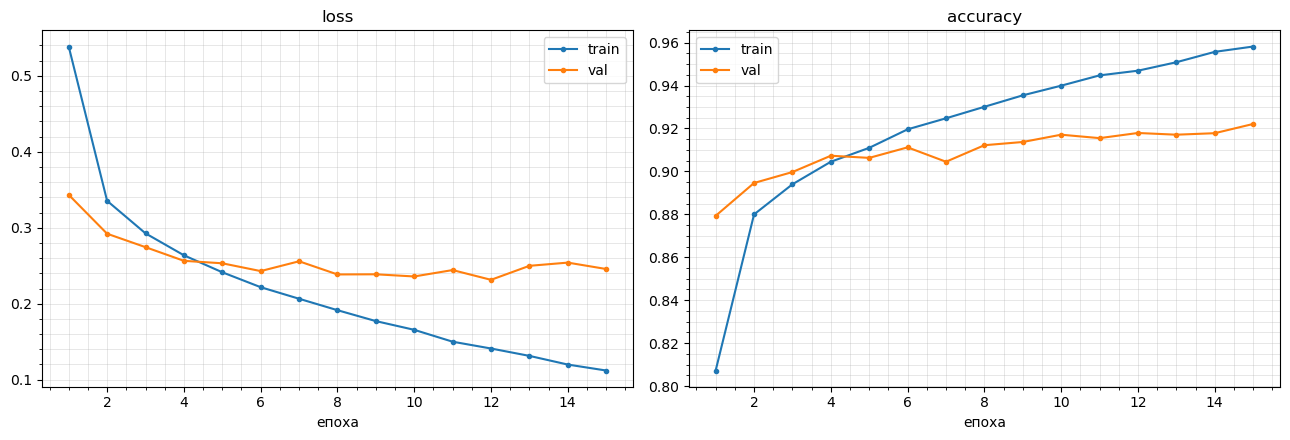

In [11]:
# Крок 5. Криві навчання
# Малюємо loss і accuracy по епохах на train і на валідації. Розходження кривих показує
# перенавчання: train далі покращується, а валідація застигає. Видно, що val_loss спочатку падає, а
# потім розвертається вгору - з цього моменту мережа вже переучується.
h = history.history
epochs_range = range(1, len(h["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(epochs_range, h["loss"], marker="o", ms=3, label="train")
axes[0].plot(epochs_range, h["val_loss"], marker="o", ms=3, label="val")
axes[0].set_title("loss")
axes[0].set_xlabel("епоха")
axes[0].legend()
axes[1].plot(epochs_range, h["accuracy"], marker="o", ms=3, label="train")
axes[1].plot(epochs_range, h["val_accuracy"], marker="o", ms=3, label="val")
axes[1].set_title("accuracy")
axes[1].set_xlabel("епоха")
axes[1].legend()
plt.tight_layout()
plt.show()

In [12]:
# Крок 6. Оцінка на тестовому наборі
# Перевіряємо мережу на тесті - даних, яких вона не бачила ні під час тренування, ні на валідації.
# Це чесна оцінка якості.
test_loss, base_test_acc = model.evaluate(x_test_prep, y_test, verbose=0)
print(f"test accuracy: {base_test_acc:.4f} | test loss: {test_loss:.4f}")

test accuracy: 0.9184 | test loss: 0.2646


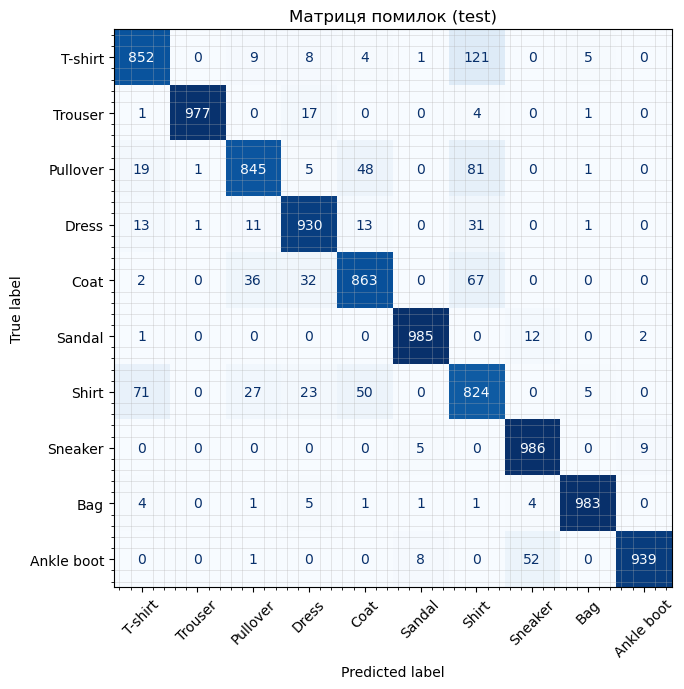

In [13]:
# Матриця помилок з назвами класів: по діагоналі - правильні відповіді, поза нею - де мережа плутає.
# Найбільше плутанини серед схожого "верху" - Shirt з T-shirt, Pullover і Coat.
y_pred = model.predict(x_test_prep, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues",
                                                            colorbar=False, xticks_rotation=45)
ax.grid(False)
plt.title("Матриця помилок (test)")
plt.tight_layout()
plt.show()

помилок: 816 з 10000


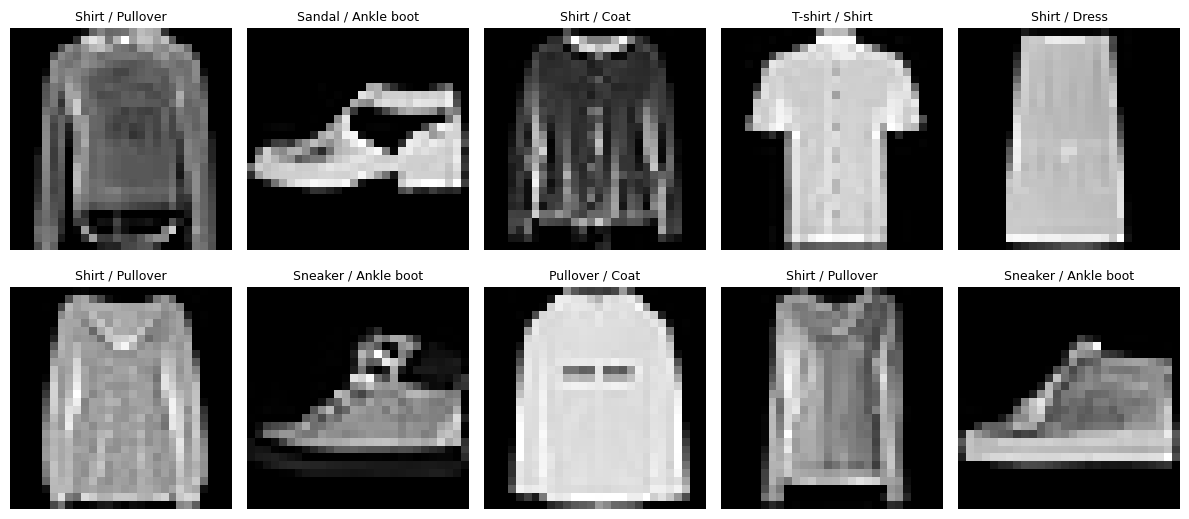

In [14]:
# Дивимось кілька прикладів, де мережа помилилась: над картинкою - що вона передбачила і яка
# правильна відповідь. Часто це справді схожі речі, які й людині легко переплутати.
wrong = np.where(y_pred != y_test)[0]
print(f"помилок: {len(wrong)} з {len(y_test)}")
fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))
for ax, idx in zip(axes.ravel(), wrong[:10]):
    ax.imshow(x_test[idx], cmap="gray")
    ax.set_title(f"{class_names[y_pred[idx]]} / {class_names[y_test[idx]]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [15]:
# Крок 7. Експеримент з оптимізаторами
# Головна частина. Беремо ту саму базову CNN і тренуємо її з різними оптимізаторами, а решту лишаємо
# однаковою (архітектура, кількість епох, batch, seed) - так порівняння чесне. Оптимізатор - це
# правило, за яким мережа оновлює ваги. Дивимось, який швидше й нижче опускає похибку. Learning rate
# у кожного лишаємо за замовчуванням (порівнюємо "з коробки").
def build_cnn():
    return keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
        keras.layers.MaxPooling2D(),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(10, activation="softmax"),
    ])

optimizers = {
    "SGD": lambda: keras.optimizers.SGD(),
    "SGD+momentum": lambda: keras.optimizers.SGD(momentum=0.9),
    "SGD+Nesterov": lambda: keras.optimizers.SGD(momentum=0.9, nesterov=True),
    "RMSprop": lambda: keras.optimizers.RMSprop(),
    "Adam": lambda: keras.optimizers.Adam(),
}

histories = {}
rows = []
for name, make_opt in optimizers.items():
    keras.utils.set_random_seed(42)
    m = build_cnn()
    m.compile(optimizer=make_opt(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = m.fit(x_train, y_train, validation_data=(x_val, y_val),
                 epochs=10, batch_size=128, verbose=0)
    opt_test = m.evaluate(x_test_prep, y_test, verbose=0)[1]
    histories[name] = hist.history
    rows.append({"оптимізатор": name,
                 "val_acc": round(hist.history["val_accuracy"][-1], 4),
                 "test_acc": round(opt_test, 4),
                 "train_loss_остання": round(hist.history["loss"][-1], 4)})
results = pd.DataFrame(rows)
results

,оптимізатор,val_acc,test_acc,train_loss_остання
0,SGD,0.8442,0.8353,0.4618
1,SGD+momentum,0.8918,0.8852,0.2832
2,SGD+Nesterov,0.8984,0.8933,0.2793
3,RMSprop,0.9200,0.9123,0.1616
4,Adam,0.9191,0.9133,0.1635


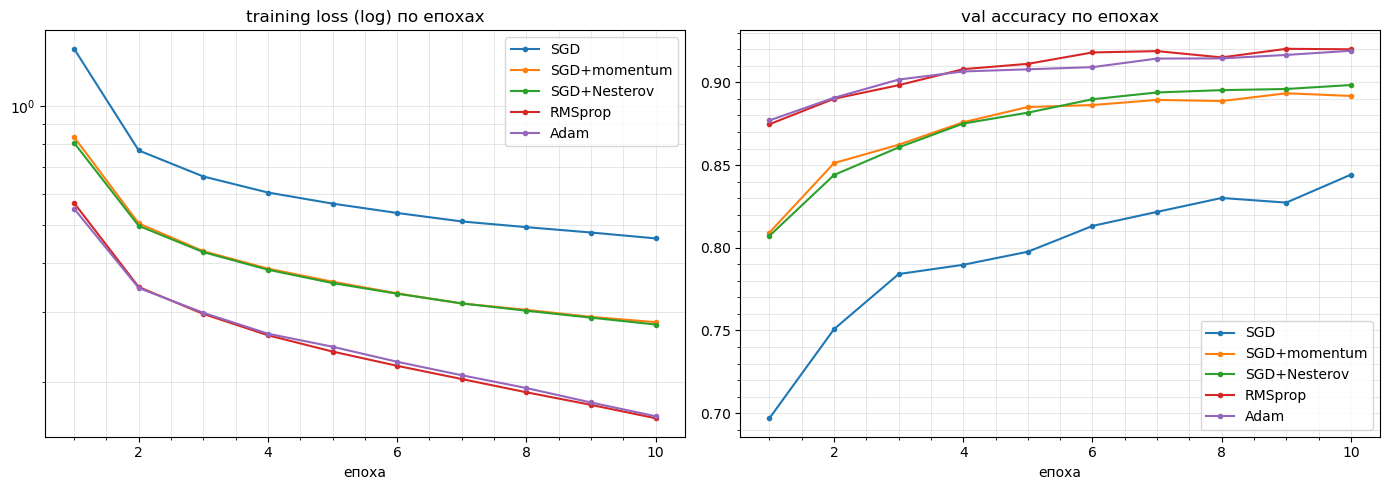

In [16]:
# Зліва training loss у log-шкалі по епохах (цей графік показує, наскільки швидше кожен
# оптимізатор опускає похибку), справа val accuracy по епохах. Видно, хто збігається швидше й до
# нижчої похибки.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories.items():
    ep = range(1, len(h["loss"]) + 1)
    axes[0].plot(ep, h["loss"], marker="o", ms=3, label=name)
    axes[1].plot(ep, h["val_accuracy"], marker="o", ms=3, label=name)
axes[0].set_yscale("log")
axes[0].set_title("training loss (log) по епохах")
axes[0].set_xlabel("епоха")
axes[0].legend()
axes[1].set_title("val accuracy по епохах")
axes[1].set_xlabel("епоха")
axes[1].legend()
plt.tight_layout()
plt.show()

In [17]:
# Крок 8. Фінальна модель
# Беремо найкращий оптимізатор з експерименту (Adam) і будуємо сильнішу мережу: по дві згортки в
# кожному блоці, BatchNormalization (вирівнює активації, з ним навчання стабільніше й швидше) і
# Dropout проти перенавчання. Тренуємо на фіксованій кількості
# епох.
keras.utils.set_random_seed(42)
model_final = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.25),
    keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.25),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation="softmax"),
])
model_final.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_final.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469,098 (1.79 MB)

 Trainable params: 468,458 (1.79 MB)

 Non-trainable params: 640 (2.50 KB)

In [18]:
# Тренуємо фінальну модель 20 епох.
history_final = model_final.fit(x_train, y_train, validation_data=(x_val, y_val),
                                epochs=20, batch_size=128, verbose=2)

Epoch 1/20


391/391 - 20s - 52ms/step - accuracy: 0.8366 - loss: 0.4684 - val_accuracy: 0.5421 - val_loss: 1.2352


Epoch 2/20


391/391 - 19s - 48ms/step - accuracy: 0.8926 - loss: 0.3031 - val_accuracy: 0.9074 - val_loss: 0.2550


Epoch 3/20


...

391/391 - 19s - 48ms/step - accuracy: 0.9572 - loss: 0.1151 - val_accuracy: 0.9380 - val_loss: 0.1884


Epoch 19/20


391/391 - 19s - 48ms/step - accuracy: 0.9608 - loss: 0.1076 - val_accuracy: 0.9260 - val_loss: 0.2203


Epoch 20/20


391/391 - 20s - 50ms/step - accuracy: 0.9606 - loss: 0.1059 - val_accuracy: 0.9371 - val_loss: 0.1960


In [19]:
# Порівнюємо фінальну модель з базовою на тесті. Сильніша архітектура з BatchNorm і Dropout плюс
# Adam дають кращий результат, ніж проста базова CNN.
final_loss, final_acc = model_final.evaluate(x_test_prep, y_test, verbose=0)
print(f"базова CNN:    test accuracy {base_test_acc:.4f}")
print(f"фінальна CNN:  test accuracy {final_acc:.4f}")

базова CNN:    test accuracy 0.9184
фінальна CNN:  test accuracy 0.9327


In [20]:
# Висновки
# - Fashion-MNIST - 70000 картинок одягу 28x28, 10 класів, рівні. Пікселі нормалізували і додали
#   вимір каналу (28,28,1), бо згортка працює з картинкою, а не з плоским вектором.
# - Базова CNN (два блоки згортка+пулінг) дає на тесті ~92%. Згортки вловлюють форму одягу краще,
#   ніж прості щільні шари.
# - Головний експеримент - різні оптимізатори на тій самій мережі: чистий SGD найповільніший і
#   найгірший (~84%), momentum і Nesterov помітно краще (~89-90%), а Adam і RMSprop збігаються
#   найшвидше й дають найвищу точність (~92%). Adam - зручний варіант за замовчуванням.
# - Фінальна сильніша модель (подвійні згортки + BatchNorm + Dropout + Adam) піднімає тест до
#   ~93.3%.
# - Найбільше мережа плутає схожий верхній одяг: Shirt з T-shirt, Pullover і Coat.